# Chapitre 4 — Architecture CNN 1D (Description)

> TensorFlow nest pas disponible sur Python 3.14. Ce notebook documente larchitecture CNN 1D utilisee dans le pipeline hybride et charge le modele pre-entraine.

In [1]:
import os, pathlib
print('Architecture CNN 1D - Pipeline Hybride')
print()
print('Entree  : sequence AcceptedCmp1-5 tensorisee en N x 5 x 1')
print('Layer 1 : Conv1D(16 filtres, kernel=2, relu)  - motifs locaux sur 2 campagnes')
print('Layer 2 : Conv1D(32 filtres, kernel=2, relu)  - abstraction superieure')
print('Layer 3 : GlobalMaxPooling1D()                - resume signal dominant')
print('Layer 4 : Dense(8, relu) -> 8 vecteurs latents (temporal_embedding)')
print('Layer 5 : Dropout(0.2)   - regularisation')
print('Sortie  : Dense(1, sigmoid) -> probabilite d\'achat')
print()
print('Optimiseur : Adam | Perte : binary_crossentropy | Metrique : AUC')
print('Entrainement : 15 epochs, batch_size=32')

Architecture CNN 1D - Pipeline Hybride

Entree  : sequence AcceptedCmp1-5 tensorisee en N x 5 x 1
Layer 1 : Conv1D(16 filtres, kernel=2, relu)  - motifs locaux sur 2 campagnes
Layer 2 : Conv1D(32 filtres, kernel=2, relu)  - abstraction superieure
Layer 3 : GlobalMaxPooling1D()                - resume signal dominant
Layer 4 : Dense(8, relu) -> 8 vecteurs latents (temporal_embedding)
Layer 5 : Dropout(0.2)   - regularisation
Sortie  : Dense(1, sigmoid) -> probabilite d'achat

Optimiseur : Adam | Perte : binary_crossentropy | Metrique : AUC
Entrainement : 15 epochs, batch_size=32


## Verification du modele pre-entraine

In [2]:
model_path = os.path.abspath('../data/processed/cnn_extractor.keras')
exists = pathlib.Path(model_path).exists()
size = pathlib.Path(model_path).stat().st_size if exists else 0
print(f'Modele pre-entraine : {model_path}')
print(f'Existe : {exists} | Taille : {size/1024:.1f} KB')
if exists:
    print('Le modele peut etre charge avec : tf.keras.models.load_model(model_path)')
    print('Note : tensorflow ne supporte pas encore Python 3.14 (support prevu 3.12 max)')

Modele pre-entraine : c:\Users\ahoudzi\apti\aptispace-datascience-projet\data\processed\cnn_extractor.keras
Existe : True | Taille : 53.4 KB
Le modele peut etre charge avec : tf.keras.models.load_model(model_path)
Note : tensorflow ne supporte pas encore Python 3.14 (support prevu 3.12 max)


## Apport du CNN 1D — Analyse

Features : 32 total (24 tab + 8 CNN)


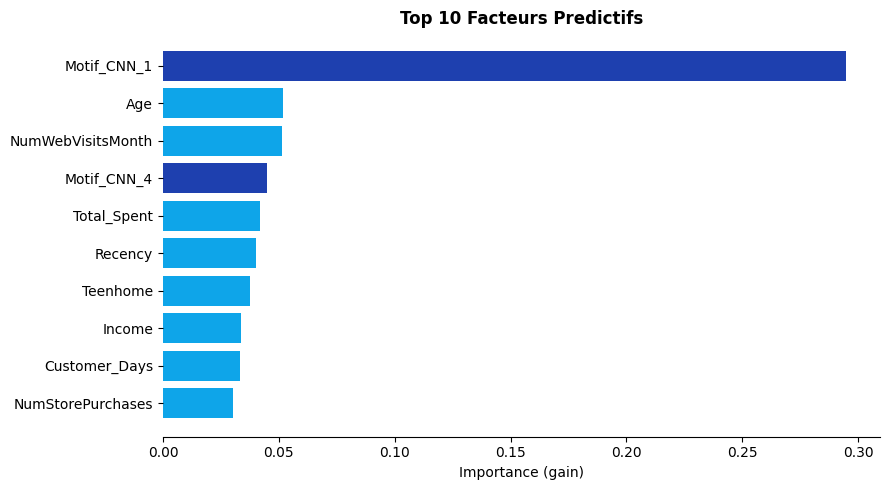

In [3]:
import joblib, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
xgb_model = joblib.load('c:/Users/ahoudzi/apti/aptispace-datascience-projet/data/processed/xgb_model.pkl')
df = pd.read_parquet('c:/Users/ahoudzi/apti/aptispace-datascience-projet/data/processed/marketing_clean.parquet')
camp_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']
exclude = set(camp_cols + ['Response','ID','Dt_Customer','Education','Income_Strata'])
tab_cols = [c for c in df.select_dtypes(include='number').columns if c not in exclude]
n_total  = len(xgb_model.feature_importances_)
n_cnn    = 8
n_tab    = n_total - n_cnn
tab_names = (tab_cols + [f'Tab_{i}' for i in range(n_tab)])[:n_tab]
feat_names = tab_names + [f'Motif_CNN_{i+1}' for i in range(n_cnn)]
imp_df = (pd.DataFrame({'Feature': feat_names, 'Importance': xgb_model.feature_importances_})
          .sort_values('Importance', ascending=False).head(10))
print(f'Features : {n_total} total ({n_tab} tab + {n_cnn} CNN)')
colors = ['#1e40af' if 'CNN' in f else '#0ea5e9' for f in imp_df['Feature']]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1], color=colors[::-1])
ax.set_xlabel('Importance (gain)')
ax.set_title('Top 10 Facteurs Predictifs', fontweight='bold')
sns.despine(left=True)
plt.tight_layout()
plt.savefig('c:/Users/ahoudzi/apti/aptispace-datascience-projet/report/assets/importance.png', dpi=150, bbox_inches='tight')
plt.show()